# Language Models for Text Classification with the AG News Dataset — Student Version

In this notebook, you will progressively build a small prompting-based text classification pipeline with the **AG News** dataset.

## Learning goals
- load and inspect a text classification dataset
- design **zero-shot** and **few-shot** prompts
- query **two LLM APIs** (**Groq** and **Mistral**)
- normalize model outputs
- evaluate predictions on a small test subset
- reflect on strengths and limitations of prompting for classification


## 1. Setup

This notebook should use:
- `datasets` for AG News
- `pandas` and `matplotlib` for quick inspection
- `groq` for one API
- `mistralai` for a second API

> Keep API keys out of the notebook when possible.

In [ ]:
# TODO: uncomment and run if needed
# !pip install -q datasets pandas matplotlib groq mistralai

In [1]:
import os
import re
import json
import random
import time
from typing import List, Dict, Optional

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from openai import OpenAI
from groq import Groq

c:\Users\ferna\Documents\GitHub\AP\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:

import os
import random
from dotenv import load_dotenv

load_dotenv()
SEED = 42
random.seed(SEED)

# Small subsets keep the demo fast and avoid exhausting free quotas.
TRAIN_SUBSET = 24
TEST_SUBSET = 20

LABELS = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech",
}

# Lê as chaves das variáveis de ambiente
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
MISTRAL_API_KEY = os.getenv("MISTRAL_API_KEY")

# Modelos
GROQ_MODEL = "llama-3.3-70b-versatile"
MISTRAL_MODEL = "mistral-small-latest"

print("Groq key loaded:", GROQ_API_KEY is not None)
print("Mistral key loaded:", MISTRAL_API_KEY is not None)

Groq key loaded: True
Mistral key loaded: True


## 2. Load and inspect AG News

AG News contains four topic classes:
1. World
2. Sports
3. Business
4. Sci/Tech

Each example contains a piece of text and a numeric label.

In [6]:
print("Loading AG News...")
dataset = load_dataset("ag_news")

train_data = dataset["train"].shuffle(seed=SEED)
test_data = dataset["test"].shuffle(seed=SEED)

if TRAIN_SUBSET is not None:
    train_data = train_data.select(range(TRAIN_SUBSET))
if TEST_SUBSET is not None:
    test_data = test_data.select(range(TEST_SUBSET))

print(dataset)
print("Train subset size:", len(train_data))
print("Test subset size:", len(test_data))

Loading AG News...


c:\Users\ferna\Documents\GitHub\AP\venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ferna\.cache\huggingface\hub\datasets--ag_news. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 7600/7600 [00:00<00:00, 341570.34 examples/s]


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Train subset size: 24
Test subset size: 20


In [7]:
df_train = pd.DataFrame(train_data)
df_test = pd.DataFrame(test_data)

df_train["label_name"] = df_train["label"].map(LABELS)
df_test["label_name"] = df_test["label"].map(LABELS)

display(df_train.head())
display(df_test.head())

,text,label,label_name
0,Bangladesh paralysed by strikes Opposition act...,0,World
1,Desiring Stability Redskins coach Joe Gibbs ex...,1,Sports
2,Will Putin #39;s Power Play Make Russia Safer?...,0,World
3,U2 pitches for Apple New iTunes ads airing dur...,3,Sci/Tech
4,S African TV in beheading blunder Public broad...,0,World


,text,label,label_name
0,Indian board plans own telecast of Australia s...,1,Sports
1,Stocks Higher on Drop in Jobless Claims A shar...,2,Business
2,"Nuggets 112, Raptors 106 Carmelo Anthony score...",1,Sports
3,Stocks Higher on Drop in Jobless Claims A shar...,2,Business
4,REVIEW: 'Half-Life 2' a Tech Masterpiece (AP) ...,3,Sci/Tech


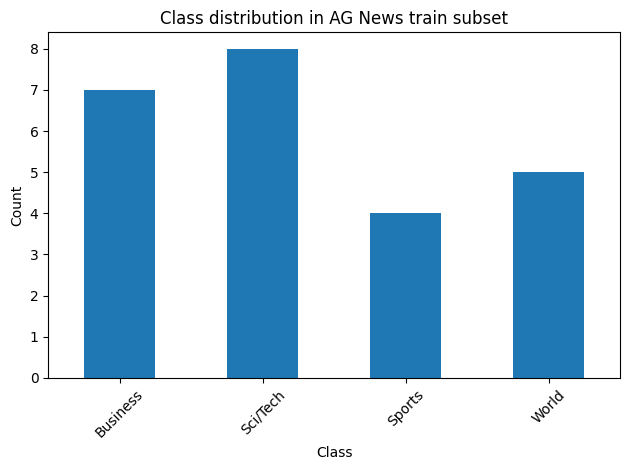

In [8]:
df_train["label_name"].value_counts().sort_index().plot(kind="bar")
plt.title("Class distribution in AG News train subset")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Build prompts

We want the model to return **only one** of these labels:
- `World`
- `Sports`
- `Business`
- `Sci/Tech`

### TODOs
- understand why constrained output matters
- compare **zero-shot** and **few-shot**
- decide what makes a good support example

In [9]:
def format_example(example):
    title = example.get("title", "").strip()
    text = example.get("text", "").strip()
    return f"Title: {title}\nText: {text}"

In [10]:
def build_zero_shot_prompt(example):
    formatted = format_example(example)
    prompt = f"""
You are a news topic classifier.

Your task is to classify the following news article into exactly one of these labels:
- World
- Sports
- Business
- Sci/Tech

Rules:
- Return exactly one label
- Do not explain your answer
- Do not return anything else

Article:
{formatted}

Label:
"""
    return prompt.strip()

In [11]:
def build_few_shot_prompt(example, support_examples):
    support_block = ""

    for ex in support_examples:
        support_block += f"{format_example(ex)}\nLabel: {LABELS[ex['label']]}\n\n"

    target = format_example(example)

    prompt = f"""
You are a news topic classifier.

Your task is to classify each news article into exactly one of these labels:
- World
- Sports
- Business
- Sci/Tech

Rules:
- Return exactly one label
- Do not explain your answer
- Do not return anything else

Here are some labeled examples:

{support_block}
Now classify this article:

{target}

Label:
"""
    return prompt.strip()

## 4. API helpers

We will compare:
1. **Groq**
2. **Mistral**

Both functions should receive a prompt and return the model's raw text output.

In [12]:
groq_client = Groq(api_key=GROQ_API_KEY)

def ask_groq(prompt, model=GROQ_MODEL):
    response = groq_client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=20,
    )
    return response.choices[0].message.content.strip()

In [13]:
mistral_client = OpenAI(
    api_key=MISTRAL_API_KEY,
    base_url="https://api.mistral.ai/v1"
)

def ask_mistral(prompt, model=MISTRAL_MODEL):
    response = mistral_client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=20,
    )
    return response.choices[0].message.content.strip()

In [14]:
VALID_LABELS = set(LABELS.values())

def normalize_prediction(text):
    if text is None:
        return None

    text = text.strip()

    if text in VALID_LABELS:
        return text

    for label in VALID_LABELS:
        if label.lower() in text.lower():
            return label

    return None

In [15]:
def evaluate_predictions(predictions, gold_ids):
    rows = []

    for pred, gold_id in zip(predictions, gold_ids):
        gold_label = LABELS[gold_id]
        rows.append({
            "gold_id": gold_id,
            "gold_label": gold_label,
            "prediction": pred,
            "correct": pred == gold_label
        })

    return pd.DataFrame(rows)

## 5. Zero-shot classification

In zero-shot prompting, the model gets **instructions only**, with **no labeled examples**.

### TODOs
- test each API on a very small subset first
- inspect the raw outputs
- check whether the model respects the required format

In [16]:
def run_experiment(
    dataset_split,
    ask_fn,
    prompt_builder,
    support_examples=None,
    sleep_seconds=0.0,
):
    predictions = []
    raw_outputs = []

    for example in dataset_split:
        try:
            if support_examples is None:
                prompt = prompt_builder(example)
            else:
                prompt = prompt_builder(example, support_examples)

            raw = ask_fn(prompt)
            pred = normalize_prediction(raw)

        except Exception as e:
            raw = f"ERROR: {e}"
            pred = None

        raw_outputs.append(raw)
        predictions.append(pred)

        if sleep_seconds > 0:
            time.sleep(sleep_seconds)

    return predictions, raw_outputs

In [17]:
tiny_test = test_data.select(range(5))
gold_tiny = [ex["label"] for ex in tiny_test]

zs_groq_preds, zs_groq_raw = run_experiment(
    tiny_test,
    ask_groq,
    build_zero_shot_prompt
)

zs_mistral_preds, zs_mistral_raw = run_experiment(
    tiny_test,
    ask_mistral,
    build_zero_shot_prompt
)

display(evaluate_predictions(zs_groq_preds, gold_tiny))
display(evaluate_predictions(zs_mistral_preds, gold_tiny))

print("Groq raw outputs:", zs_groq_raw)
print("Mistral raw outputs:", zs_mistral_raw)

,gold_id,gold_label,prediction,correct
0,1,Sports,Sports,True
1,2,Business,Business,True
2,1,Sports,Sports,True
3,2,Business,Business,True
4,3,Sci/Tech,Sci/Tech,True


,gold_id,gold_label,prediction,correct
0,1,Sports,Sports,True
1,2,Business,Business,True
2,1,Sports,Sports,True
3,2,Business,Business,True
4,3,Sci/Tech,Sci/Tech,True


Groq raw outputs: ['Sports', 'Business', 'Sports', 'Business', 'Sci/Tech']
Mistral raw outputs: ['Sports', 'Business', 'Sports', 'Business', 'Sci/Tech']


## 6. Few-shot classification

In few-shot prompting, we include a small number of labeled examples in the prompt.

### TODOs
- build a support set
- start with **one example per class**
- later try more examples
- reflect on whether support example choice changes the results

In [18]:
support_examples = []
seen = set()

for ex in train_data:
    label = ex["label"]
    if label not in seen:
        support_examples.append(ex)
        seen.add(label)
    if len(seen) == 4:
        break

for ex in support_examples:
    print("Label:", LABELS[ex["label"]])
    print(format_example(ex))
    print("-" * 80)

Label: World
Title: 
Text: Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally.
--------------------------------------------------------------------------------
Label: Sports
Title: 
Text: Desiring Stability Redskins coach Joe Gibbs expects few major personnel changes in the offseason and wants to instill a culture of stability in Washington.
--------------------------------------------------------------------------------
Label: Sci/Tech
Title: 
Text: U2 pitches for Apple New iTunes ads airing during baseball games Tuesday will feature the advertising-shy Irish rockers.
--------------------------------------------------------------------------------
Label: Business
Title: 
Text: Economy builds steam in KC Fed district The economy continued to strengthen in September and early October in the Great Plains and Rocky Mountain regions covered by the Tenth Federal Rese

In [19]:
gold_test = [ex["label"] for ex in test_data]

fs_groq_preds, fs_groq_raw = run_experiment(
    test_data,
    ask_groq,
    build_few_shot_prompt,
    support_examples=support_examples
)

fs_mistral_preds, fs_mistral_raw = run_experiment(
    test_data,
    ask_mistral,
    build_few_shot_prompt,
    support_examples=support_examples
)

df_fs_groq = evaluate_predictions(fs_groq_preds, gold_test)
df_fs_mistral = evaluate_predictions(fs_mistral_preds, gold_test)

display(df_fs_groq)
display(df_fs_mistral)

,gold_id,gold_label,prediction,correct
0,1,Sports,Sports,True
1,2,Business,Business,True
2,1,Sports,Sports,True
3,2,Business,Business,True
4,3,Sci/Tech,Sci/Tech,True
5,0,World,Business,False
6,2,Business,Business,True
7,2,Business,Business,True
8,3,Sci/Tech,Sci/Tech,True
9,2,Business,Business,True


,gold_id,gold_label,prediction,correct
0,1,Sports,Sports,True
1,2,Business,Business,True
2,1,Sports,Sports,True
3,2,Business,Business,True
4,3,Sci/Tech,Sci/Tech,True
5,0,World,World,True
6,2,Business,Business,True
7,2,Business,Business,True
8,3,Sci/Tech,Sci/Tech,True
9,2,Business,Business,True


## 7. Compare zero-shot vs few-shot

You should now have four settings:
- Groq zero-shot
- Groq few-shot
- Mistral zero-shot
- Mistral few-shot

### TODOs
- compute accuracy for each setting
- compare the numbers
- identify at least 2 error cases

,setting,accuracy
0,Groq zero-shot,1.00
1,Groq few-shot,0.95
2,Mistral zero-shot,1.00
3,Mistral few-shot,0.95


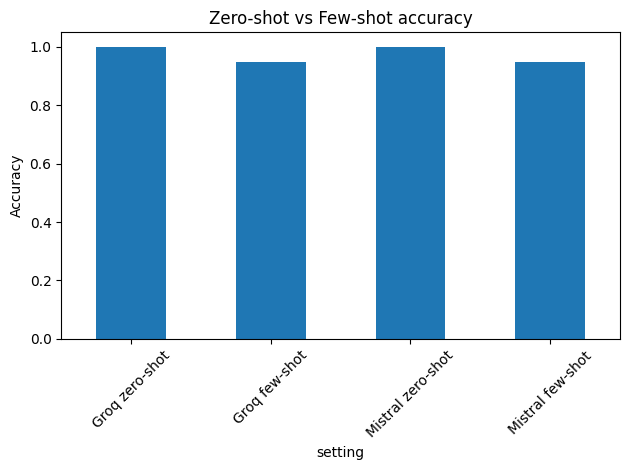

In [20]:
def accuracy(preds, gold_ids):
    correct = 0
    total = len(gold_ids)

    for pred, gold_id in zip(preds, gold_ids):
        if pred == LABELS[gold_id]:
            correct += 1

    return correct / total if total > 0 else 0.0

results = {
    "Groq zero-shot": accuracy(zs_groq_preds, gold_tiny),
    "Groq few-shot": accuracy(fs_groq_preds, gold_test),
    "Mistral zero-shot": accuracy(zs_mistral_preds, gold_tiny),
    "Mistral few-shot": accuracy(fs_mistral_preds, gold_test),
}

results_df = pd.DataFrame(
    [{"setting": k, "accuracy": v} for k, v in results.items()]
)

display(results_df)

results_df.plot(x="setting", y="accuracy", kind="bar", legend=False)
plt.title("Zero-shot vs Few-shot accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Reflection questions

Answer briefly in your own words.

1. Did few-shot improve performance?
2. Which classes seemed easiest or hardest?
3. Were the outputs always clean and easy to parse?
4. How sensitive were the results to prompt wording?
5. What are the limitations of API-based prompting for classification?
6. When would you prefer a supervised classifier instead?

## 9. Optional extensions

Choose one or more:

- Try **2 support examples per class**
- Compare **headline only** vs **full text**
- Force the model to output a **JSON object**
- Build a **confusion matrix**
- Measure **latency** per API
- Estimate **cost / quota usage**
- Intentionally use **biased support examples** and observe what changes

In [21]:
# Tornar o normalize_prediction mais robusto

def normalize_prediction(text):
    if text is None:
        return None

    text = text.strip()

    aliases = {
        "world": "World",
        "sports": "Sports",
        "business": "Business",
        "sci/tech": "Sci/Tech",
        "scitech": "Sci/Tech",
        "science/technology": "Sci/Tech",
        "science and technology": "Sci/Tech",
        "technology": "Sci/Tech",
    }

    if text in VALID_LABELS:
        return text

    lowered = text.lower()
    for k, v in aliases.items():
        if k in lowered:
            return v

    return None

In [22]:
# Medir quantos None aparecem
print("Groq invalid outputs:", sum(p is None for p in fs_groq_preds))
print("Mistral invalid outputs:", sum(p is None for p in fs_mistral_preds))

Groq invalid outputs: 0
Mistral invalid outputs: 0


## 10. Final takeaway

Large language models can perform classification through prompting alone.

### Before finishing, make sure you completed:
- [ ] dataset loading
- [ ] zero-shot prompt
- [ ] few-shot prompt
- [ ] Groq helper
- [ ] Mistral helper
- [ ] normalization
- [ ] evaluation
- [ ] comparison
- [ ] reflection